In [65]:
import zipfile
import numpy as np
import os
import imageio
import pandas as pd
import sklearn.datasets
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

In [14]:
# Read the images from the zip file using the zipfile library.
zip_path = "CroppedYale.zip"
extract_path = "CroppedYale"

# Extract images from the zip file and store it under "CroppedYale".
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [94]:
# Create the array of image vectors. 

dataset_path = "CroppedYale/CroppedYale"

images = [] # To store the images 
labels = [] # To store the labels. 

for subject in sorted(os.listdir(dataset_path)):
    
    subject_path = os.path.join(dataset_path, subject)
    
    if not os.path.isdir(subject_path):
        continue
        
    for file in os.listdir(subject_path):
        
        # Skip ambient images if any have been detected. 
        if "Ambient" in file:
            continue
            
        if file.endswith(".pgm"):
            
            path = os.path.join(subject_path, file)
            img = imageio.imread(path)
            
            images.append(img) # Append images. 
            labels.append(subject) # Append label to be the number of the person whose image it is. 

X = np.array(images) # Comvert to array.
y = np.array(labels) # Convert labels to array

print("Dataset shape:", X.shape)

/tmp/ipykernel_442/3605071814.py:22: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


Dataset shape: (2414, 192, 168)


In [95]:
# Normalize the image vectors. 
# This is important for training the CNN. 

X = X.astype("float32") 
X = (X - X.min()) / (X.max() - X.min()) 
print(X.shape)

(2414, 192, 168)


In [96]:
# This function generates occludede images with a mask around the eye area of the person in the image. 
def cnn_occlusion(img):
    occluded = img.copy()
    
    # same region used in RPCA notebook
    occluded[20:90, 10:-10] = 0
    
    return occluded # Return a occluded image. 

In [97]:
# Generate array of occluded images . 
X_occluded = np.array([cnn_occlusion(img) for img in X]) 

In [98]:
print(X_occluded.shape)

(2414, 192, 168)


In [99]:
# Add channels. 
# We add one chanel only because our images are in greyscale. 
X_clean_cnn = np.expand_dims(X, axis=1)
X_occluded_cnn = np.expand_dims(X_occluded, axis=1)

print(X_clean_cnn.shape)

(2414, 1, 192, 168)


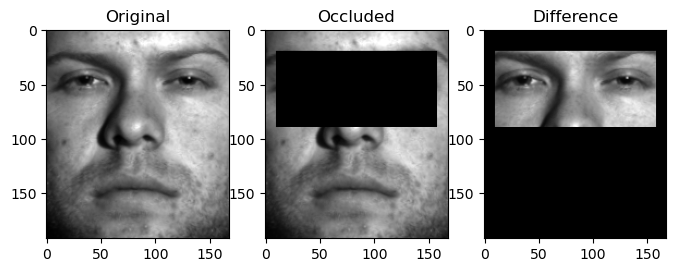

In [100]:
# Confirm if the occlusion function worked. 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(X[0], cmap="gray")

plt.subplot(1,3,2)
plt.title("Occluded")
plt.imshow(X_occluded[0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Difference")
plt.imshow(X[0] - X_occluded[0], cmap="gray")

plt.show()

In [101]:
# Train test split the occluded images and their clean counterpart. 
X_train_occ, X_test_occ, X_train_clean, X_test_clean = train_test_split(
    X_occluded,
    X,
    test_size=0.2,
    random_state=42)

In [102]:
# Add channels similar to earlier. 
X_train_occ = np.expand_dims(X_train_occ,1)
X_test_occ = np.expand_dims(X_test_occ,1)

X_train_clean = np.expand_dims(X_train_clean,1)
X_test_clean = np.expand_dims(X_test_clean,1)

In [103]:
print(X_train_occ.shape[0])

1931


In [104]:
# Converting the training and testing image sets into tensors. 
X_train_occ = torch.tensor(X_train_occ, dtype=torch.float32)
X_train_clean = torch.tensor(X_train_clean, dtype=torch.float32)

X_test_occ = torch.tensor(X_test_occ, dtype=torch.float32)
X_test_clean = torch.tensor(X_test_clean, dtype=torch.float32)

In [105]:
# The train and test image sets that have been converted into tensors. 
train_dataset = TensorDataset(X_train_occ, X_train_clean)
test_dataset = TensorDataset(X_test_occ, X_test_clean)

# Use the train_loader to decide the batch size to be used for each epoch. The images are chosen randomly through setting the parameter
# shuffle = true. 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [106]:
# Here we initialize the U-net and its layers. 
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder:
        # Here we declare the 2d convolution layers. 
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1) # Channels = 1, ouput channels = 32, kernel size = 3, padding = 1.
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.enc3 = nn.Conv2d(64, 128, 3, padding=1)

        # Decoder:
        # Deconvoulition process
        self.dec1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        # Ouput one resulting image. 
        self.out = nn.Conv2d(32, 1, 1)

        self.pool = nn.MaxPool2d(2)

    # This function performs the forward pass of the training. 
    def forward(self, x):

        # Encoder:
        e1 = F.relu(self.enc1(x)) # Pass through the first layer and apply ReLu. ReLu introduces non-linearity. 
        p1 = self.pool(e1) # Perform pooling. 

        # Perform this similarly for the other layers too. 
        e2 = F.relu(self.enc2(p1))
        p2 = self.pool(e2)

        e3 = F.relu(self.enc3(p2))

        # Decoder:
        d1 = self.dec1(e3)
        d1 = d1 + e2[:, :, :d1.shape[2], :d1.shape[3]] 

        d2 = self.dec2(d1)
        d2 = d2 + e1[:, :, :d2.shape[2], :d2.shape[3]]

        out = torch.sigmoid(self.out(d2))

        return out

In [107]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

In [108]:
# Define the criterion for training, and the optimizer to be used. 
# We use ADAM which is Adaptive Momentum Gradient descent. Uses momentum in calculating the update and dynamically updates the learning 
# rate.
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [109]:
# Train the U-net for 75 epochs. 
epochs = 75

# Loop over number of epochs.
for epoch in range(epochs):

    # Start training. 
    model.train()
    total_loss = 0

    # Loop over every occluded and clean image pair. 
    for occluded, clean in train_loader:

        # Load occluded and clean images to GPU memory.
        occluded = occluded.to(device)
        clean = clean.to(device)

        # We reinitialize the gradient to 0 in every batch of occluded and clean image pairs. 
        optimizer.zero_grad()

        # Perform the convolution and get the output reconstructed image.
        output = model(occluded)

        # Caclulate the loss or error rate based on the criterion we chose which was MSELoss.
        # MSELoss compares each pixel and squares the difference to the pixel in the target.
        # It then averages this squared error to get the mean squared loss. 
        loss = criterion(output, clean)

        # Perform backpropogation and perform update of the weights using gradient descent. 
        # Note: The optimization in done through mini-batch gradient descent. 
        loss.backward()
        optimizer.step()

        # Sum the loss to get the total. 
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.029615576463666828
Epoch 2, Loss: 0.017663022572528726
Epoch 3, Loss: 0.01684755186958254
Epoch 4, Loss: 0.015969925883326155
Epoch 5, Loss: 0.015663908471253294
Epoch 6, Loss: 0.015718209611113407
Epoch 7, Loss: 0.015295976688238707
Epoch 8, Loss: 0.015050618970874419
Epoch 9, Loss: 0.014959236483805436
Epoch 10, Loss: 0.014589871610861178
Epoch 11, Loss: 0.014651582530153192
Epoch 12, Loss: 0.014468371337048772
Epoch 13, Loss: 0.014605801837318692
Epoch 14, Loss: 0.014273614730408862
Epoch 15, Loss: 0.014184394481876665
Epoch 16, Loss: 0.01409784719070866
Epoch 17, Loss: 0.013992638611965928
Epoch 18, Loss: 0.013806413220287847
Epoch 19, Loss: 0.013937572355974804
Epoch 20, Loss: 0.013731646605513313
Epoch 21, Loss: 0.013856831938028336
Epoch 22, Loss: 0.013703496256950965
Epoch 23, Loss: 0.013721869473368668
Epoch 24, Loss: 0.013673782502570429
Epoch 25, Loss: 0.013571822215333458
Epoch 26, Loss: 0.0135123423139049
Epoch 27, Loss: 0.013647416745089302
Epoch 28, Loss

In [113]:
# Generate reconstructions of the images. 
model.eval()

with torch.no_grad():
    sample = X_test_occ[:1].to(device)

    reconstruction = model(sample)

reconstruction = reconstruction.cpu().numpy()

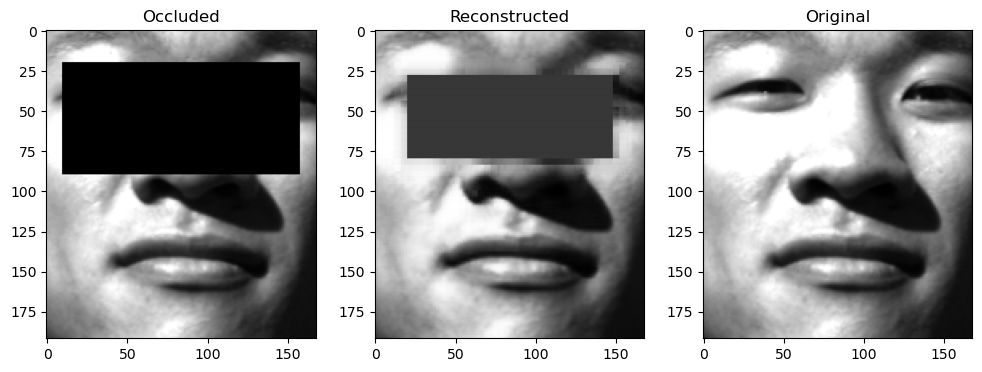

In [123]:
# Visualize the reconstruction of a particular image as an example. 
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Occluded")
plt.imshow(X_test_occ[0][0], cmap='gray')

plt.subplot(1,3,2)
plt.title("Reconstructed")
plt.imshow(reconstruction[0][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Original")
plt.imshow(X_test_clean[0][0], cmap='gray')

plt.show()

It appears that the U-net shrunk the mask while reconstructing, and also changed the coloring of the mask to match the lighting and gradients throughout the rest of the image. <br>
It does not fully reconstruct the eyes of the person. 